# Seams in the DEM

Every generator's DEM comes from USGS Astropedia's GLD100 (`dem_ortho.fetch_dem`), warped from the
file's own Equirectangular grid onto each entry's local grid. GLD100 is one global file, but it can
still go wrong along a few lines:

- **0° longitude**: the file is centered on 180°, so its raster edges meet at 0°, and an AOI there
  needs data from both ends of the file.
- **±60° latitude, and 270° longitude between them**: GLD100 is itself put together from parts
  that meet there (below).

The planned SLDEM2015 mosaic (`docs/proposed-tasks/vira-dem-sources.md`) adds seams of its own:
SLDEM2015's 512-ppd tiles are 45° of longitude by 30° of latitude, and it meets GLD100 at ±60°.
This notebook probes every point where those tiles meet (`seam_probes.DEM_SEAMS`; 180°, the branch
cut of longitude itself, is one of the meridians), so the same probes give a baseline now and a
comparison once the mosaic exists.

Each probe renders a synthetic 200 km square through `fetch_dem`'s own read-and-warp, *before*
`dem_ortho.hole_fill_dem`, so a coverage gap shows as `NaN` instead of being filled over, and
measures each seam crossing it the same way `reflectance_seams.ipynb` does for the WAC_EMP mosaic.
`tests/test_dem_seams.py` runs the same probes against the same limits
(`seam_probes.dem_thresholds`).

In [1]:
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from rasterio.windows import Window

from trntest import cache, dem_ortho, seam_plotting, seam_probes
from trntest.config import MOON_RADIUS_M, load_config

SOURCE = "dem_gld100"
config = load_config()
source = seam_probes.SOURCES[SOURCE]
results = seam_probes.run_source(SOURCE, config)
table = seam_probes.metrics_table(results)
health = seam_probes.probe_health_table(results, source.thresholds)

## Metrics

The metrics are `reflectance_seams.ipynb`'s, computed on elevation, with `step` and `spike` in
meters rather than relative to the median:

- `nan_near`: `NaN` pixels within 3 px of the seam.
- `step`: the difference between the two sides, each extrapolated to the seam from a straight line
  fit 6-30 px out.
- `spike`: the largest deviation of a near-seam bin from its side's line.
- `gradient_ratio`: the largest near-seam median slope, divided by the reference bins'. A step or a
  line in the DEM raises it, even when the profile's mean doesn't move.

Control lines, parallel to each seam 80-320 px away, show how much terrain alone moves each one.
For elevation that is a lot: steps and spikes of tens to hundreds of meters, from ordinary
topography, so those two get no pass limit. The gradient ratio is what separates a seam from
terrain.

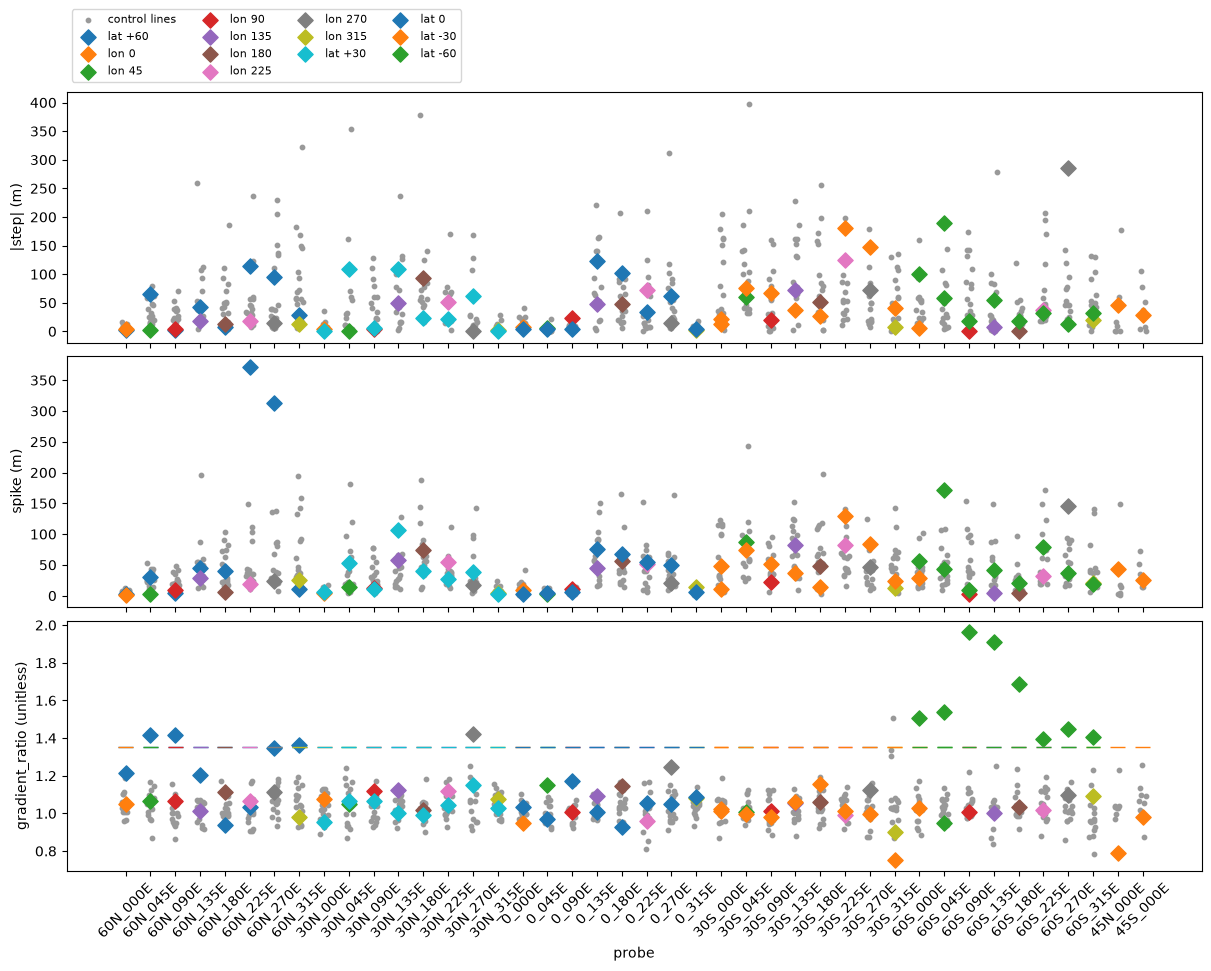

In [2]:
seam_plotting.plot_metrics_vs_controls(table, source.thresholds, step_units="m")

## Health by probe

One row per probe, as in `reflectance_seams.ipynb`. Each probe name links to a report notebook
with its renders (as a low-sun hillshade, where a step or line in the DEM shows up), profiles and
straightened seam strips. The reports aren't committed: running this notebook writes them under
`output/seam_probes/dem_gld100/`.

In [3]:
links = seam_probes.report_links(seam_probes.write_probe_reports(SOURCE, config))
seam_plotting.show_health_table(health, links)

probe,tiles,nan_px,nan_near,max_abs_step,max_spike,max_gradient_ratio,limit_use,limit_use_by,status,failed
60N_000E,1,106,106,3.454,2.729,1.216,5.048,lat +60: nan_near,FAIL,lat +60: nan_near
60N_045E,1,0,0,65.111,29.841,1.415,1.187,lat +60: gradient_ratio,FAIL,lat +60: gradient_ratio
60N_090E,1,0,0,4.497,8.793,1.418,1.195,lat +60: gradient_ratio,FAIL,lat +60: gradient_ratio
60N_135E,1,56,56,42.525,45.319,1.202,2.667,lat +60: nan_near,FAIL,lat +60: nan_near
60N_180E,1,1999,1999,13.489,40.526,1.113,95.190,lat +60: nan_near,FAIL,lat +60: nan_near
60N_225E,1,2448,2448,113.497,370.858,1.066,116.571,lat +60: nan_near,FAIL,lat +60: nan_near
60N_270E,1,2024,2024,95.358,313.732,1.345,96.381,lat +60: nan_near,FAIL,lat +60: nan_near
60N_315E,1,55,55,28.545,25.774,1.364,2.619,lat +60: nan_near,FAIL,"lat +60: nan_near, gradient_ratio"
30N_000E,1,0,0,4.626,5.765,1.076,0.217,lon 0: gradient_ratio,pass,
30N_045E,1,0,0,109.056,52.629,1.063,0.181,lat +30: gradient_ratio,pass,


Every seam, for reference:

In [4]:
display(table[~table.control].drop(columns="control").round(3))

,probe,seam,length_px,nan_near,step,spike,gradient_ratio
0,60N_000E,lat +60,1963,106,-2.880,2.729,1.216
1,60N_000E,lon 0,1960,6,-3.454,1.822,1.048
18,60N_045E,lat +60,1963,0,-65.111,29.841,1.415
19,60N_045E,lon 45,1960,0,1.735,3.294,1.068
36,60N_090E,lat +60,1963,0,-2.168,4.672,1.418
...,...,...,...,...,...,...,...
685,60S_270E,lon 270,1960,6,285.741,146.406,1.098
702,60S_315E,lat -60,1963,452,31.525,18.835,1.407
703,60S_315E,lon 315,1960,0,-20.175,19.926,1.092
720,45N_000E,lon 0,2000,0,-46.793,43.147,0.788


## GLD100's own seams, in the source file

All but one of the failing probes fail at ±60°. That line is in GLD100 itself, across its full width: the
typical (median) elevation change from one row of the file to the next jumps at the row where 60°
falls, and differs on either side of it, as if the parts north and south of it were made
separately. At 60°N, 37% of one row is also nodata, and at 60°S, 3% of one. A latitude with no seam
(30°N) is shown for comparison.

In [5]:
def row_jumps(lat_deg: float, half_rows: int = 6) -> pd.DataFrame:
    """Median and mean |row-to-row elevation change| across the whole GLD100 file near `lat_deg`."""
    with rasterio.open(cache.fetch_astropedia_gld100(config.cache_root, config.astropedia_gld100_url)) as src:
        center_row = round((MOON_RADIUS_M * np.radians(lat_deg) - src.transform.f) / src.transform.e)
        rows = src.read(1, window=Window(0, center_row - half_rows, src.width, 2 * half_rows + 1)).astype(float)
        rows[rows == src.nodata] = np.nan
    jumps = np.abs(np.diff(rows, axis=0))
    first = center_row - half_rows
    return pd.DataFrame(
        {
            "rows": [f"{first + i} -> {first + i + 1}" for i in range(len(jumps))],
            "median |dz| (m)": np.nanmedian(jumps, axis=1),
            "mean |dz| (m)": np.nanmean(jumps, axis=1),
            "nodata px in first row": np.isnan(rows[:-1]).sum(axis=1),
        }
    )


for lat in (60.0, -60.0, 30.0):
    print(f"near {lat:+g} deg")
    display(row_jumps(lat).style.format(precision=1).hide(axis="index"))

near +60 deg


rows,median |dz| (m),mean |dz| (m),nodata px in first row
5756 -> 5757,3.0,5.7,1
5757 -> 5758,3.0,5.1,1
5758 -> 5759,2.0,4.4,1
5759 -> 5760,2.0,3.8,1
5760 -> 5761,2.0,3.1,3891
5761 -> 5762,7.0,14.1,40383
5762 -> 5763,4.0,6.7,0
5763 -> 5764,4.0,6.8,0
5764 -> 5765,4.0,6.8,0
5765 -> 5766,4.0,6.8,0


near -60 deg


rows,median |dz| (m),mean |dz| (m),nodata px in first row
42144 -> 42145,5.0,8.0,0
42145 -> 42146,5.0,8.0,0
42146 -> 42147,5.0,8.0,0
42147 -> 42148,5.0,8.0,0
42148 -> 42149,5.0,8.0,0
42149 -> 42150,5.0,8.0,0
42150 -> 42151,19.0,30.5,0
42151 -> 42152,3.0,4.7,3826
42152 -> 42153,3.0,5.4,1
42153 -> 42154,4.0,6.3,1


near +30 deg


rows,median |dz| (m),mean |dz| (m),nodata px in first row
14853 -> 14854,3.0,6.3,0
14854 -> 14855,3.0,6.3,0
14855 -> 14856,3.0,6.3,0
14856 -> 14857,3.0,6.3,0
14857 -> 14858,3.0,6.2,0
14858 -> 14859,3.0,6.3,0
14859 -> 14860,3.0,6.3,0
14860 -> 14861,3.0,6.2,0
14861 -> 14862,3.0,6.3,0
14862 -> 14863,3.0,6.3,0


The other failure, 30°N 270°E, is on the 270° meridian. The file has a one-column line there, and
another at 90°, both between about 59°S and 61°N, the same span as the ±60° part: in every latitude
band in that range, the column-to-column change across the meridian differs from its neighbors'
(always larger at 270°; larger or smaller at 90°, which the probes there don't flag). 180° and 45°,
with no line, are shown for comparison. It looks as if that part was made as two halves, near side
and far side, meeting at 90° and 270°.

In [6]:
def column_jump_ratio(lon_deg: float, half_cols: int = 3) -> pd.Series:
    """Per 10-deg latitude band, the mean |column-to-column change| across `lon_deg` divided by the
    median of the neighboring column pairs' means. (Means, not medians: GLD100 is integer meters, so
    a median of a few meters jumps in whole steps.)"""
    with rasterio.open(cache.fetch_astropedia_gld100(config.cache_root, config.astropedia_gld100_url)) as src:
        x = MOON_RADIUS_M * np.radians((lon_deg - 180.0 + 180.0) % 360.0 - 180.0)
        col = round((x - src.transform.c) / src.transform.a)
        columns = src.read(1, window=Window(col - half_cols, 0, 2 * half_cols + 1, src.height)).astype(float)
        columns[columns == src.nodata] = np.nan
        lat = np.degrees((src.transform.f + (np.arange(src.height) + 0.5) * src.transform.e) / MOON_RADIUS_M)
    jumps = np.abs(np.diff(columns, axis=1))
    ratios = {}
    for lo in range(-79, 79, 10):
        mean = np.nanmean(jumps[(lat >= lo) & (lat < lo + 10)], axis=0)
        ratios[f"{lo:+d} to {lo + 10:+d}"] = mean[half_cols] / np.median(np.delete(mean, half_cols))
    return pd.Series(ratios)


display(pd.DataFrame({f"{lon:g} deg": column_jump_ratio(lon) for lon in (270.0, 90.0, 180.0, 45.0)}).round(2))

,270 deg,90 deg,180 deg,45 deg
-79 to -69,1.00,1.00,1.00,1.00
-69 to -59,1.12,1.07,1.01,1.00
-59 to -49,2.37,1.35,1.00,1.01
-49 to -39,1.65,1.51,0.99,1.00
-39 to -29,1.74,1.19,1.01,1.00
-29 to -19,1.87,0.86,0.98,1.00
-19 to -9,1.59,0.97,1.03,0.99
-9 to +1,1.54,0.71,0.99,0.98
+1 to +11,1.61,0.82,1.02,0.99
+11 to +21,1.56,0.85,0.99,0.98


## What the hole fill leaves

`fetch_dem` hole-fills the warped DEM with `dem_mosaic --hole-fill-length 50` before anything uses
it. For each probe with a gap, how much of it survives:

In [7]:
rows = []
for result in results:
    if result.nan_count == 0:
        continue
    name = result.grid.probe.name
    render = seam_probes.render_dir(SOURCE, config) / f"{name}.tif"
    filled = render.with_name(f"{name}_filled-tile-0.tif")
    dem_ortho.hole_fill_dem(render, filled)
    with rasterio.open(filled) as src:
        left = int(src.read_masks(1).size - np.count_nonzero(src.read_masks(1)))
    rows.append({"probe": name, "NaN before fill": result.nan_count, "nodata after fill": left})
display(pd.DataFrame(rows).style.hide(axis="index"))

probe,NaN before fill,nodata after fill
60N_000E,106,106
60N_135E,56,0
60N_180E,1999,1224
60N_225E,2448,2448
60N_270E,2024,1322
60N_315E,55,0
60S_000E,81,81
60S_270E,82,81
60S_315E,452,2
